In [1]:
import networkx as nx
import random as rand
import matplotlib.pyplot as plt
import numpy as np
import math

In [2]:
population_size = 1000
edge_probability = 3 / population_size

x_bound, y_bound = 100, 100
sigma = 10 # a higher sigma will make geographical density more spread out, lower more dense
num_cities = 3
num_clinics = 1 * num_cities

initial_infection_probability = 0.01
initial_viral_load = 50
initial_viral_load_std = 1 # how much deviation there is in viral load of initially infected nodes

In [3]:
city_coords = {}
for city_id in range(0, num_cities):
    city_coords[city_id] =  (rand.random() * x_bound, rand.random() * y_bound)

def choose_coordinate(city):
    center = city_coords[city]
    x, y = np.random.standard_t(center[0], sigma), np.random.standard_t(center[1], sigma)
    return (x, y)

In [4]:
def get_location(node, graph):
    if isinstance(node, int):
        return graph.nodes[node]['coordinate']
    return node[1]['coordinate']

def distance(coord1, coord2):
    return np.sqrt(
        (coord1[0] - coord2[0])**2 + 
        (coord1[1] - coord2[1])**2
    )

def node_distance(node1, node2, graph):
    coord1 = get_location(node1, graph)
    coord2 = get_location(node2, graph)
    return distance(coord1, coord2)

In [5]:
eps = 20
maximum_infection_radius = 1
# use a bump function to calculate impact of distance on infection chance; this falls off to zero outside a certain radius. 
def proximal_infection_factor(node, infectee, graph, eps = eps):
    effective_distance = node_distance(node, infectee, graph) / maximum_infection_radius
    return np.exp(1 / (effective_distance ** 2 - 1)) if effective_distance < 1 else 0
    # return np.exp(-1 * (eps * node_distance(node, infectee, graph)) ** 2)


def proximal_infection_chance(node, infectee, graph, eps = eps):
    return infection_chance(node, graph) * proximal_infection_factor(node, infectee, graph, eps = eps)

In [6]:
# uses parameters to create a simulation graph. can feed kwdargs as parameters, otherwise uses default
def setup_simulation(population_size = population_size, 
                    edge_probability = edge_probability, 
                    num_cities = num_cities, 
                    num_clinics = num_clinics, 
                    initial_infection_probability = initial_infection_probability, 
                    initial_viral_load = initial_viral_load, 
                    initial_viral_load_std = initial_viral_load_std):
    G = nx.binomial_graph(population_size, edge_probability)
    
    for node in G.nodes(data = True):
        city = np.random.randint(num_cities)
        coordinate = choose_coordinate(city)
        infected = True if rand.random() < initial_infection_probability else False
        node[1]['coordinate'] =  coordinate
        node[1]['viral_load'] =  max(infected * np.random.normal(initial_viral_load, initial_viral_load_std), 0)
        node[1]['antiviral'] =  False
        node[1]['alive'] = True
        node[1]['clinic'] = False

    # set up the proximal neighbors storage so that the later runtime is faster
    for node in G.nodes(data = True):
        node[1]['proximal_neighbors'] = []
        for possible_neighbor in G.nodes(data = True):
            if proximal_infection_factor(node, possible_neighbor, G) >= 0.01:
                node[1]['proximal_neighbors'].append(possible_neighbor)

    for i in range(0, num_clinics):
        city = np.random.randint(num_cities)
        clinic_coord = choose_coordinate(city)
        G.add_node('clinic' + str(i), clinic = True, coordinate = clinic_coord)
    
    return G

In [7]:
%%time

G = setup_simulation()

CPU times: user 5.7 s, sys: 3.89 ms, total: 5.7 s
Wall time: 5.7 s


In [8]:
def get_people(graph = G):
    return [node for node in graph.nodes(data = True) if node[1]['clinic'] == False]

In [9]:
def get_clinics(graph = G):
    return [node for node in graph.nodes(data = True) if node[1]['clinic'] == True]

In [10]:
def get_neighbors(node, graph = G):
    return [edge[1] for edge in graph.edges(node[0], data = True)]

In [11]:
def get_proximal_neighbors(node, graph = G):
    if isinstance(node, int):
        return graph.nodes[node]['proximal_neighbors']
    return node[1]['proximal_neighbors']

In [12]:
# viral load is stored in copies/mL in the blood. 
def get_vl(node, graph = G):
    if isinstance(node, int):
        return graph.nodes[node]['viral_load']
    return node[1]['viral_load']

In [13]:
def change_vl(node, amount, graph = G):
    if isinstance(node, int):
        graph.nodes[node]['viral_load'] += amount
        if graph.nodes[node]['viral_load'] < 0:
            graph.nodes[node]['viral_load'] = 0
        return
    node[1]['viral_load'] += amount
    if node[1]['viral_load'] < 0:
        node[1]['viral_load'] = 0
    # print(f'vl of {node[0]} is now {get_vl(node)}')

In [14]:
def set_vl(node, amount, graph = G):
    if isinstance(node, int):
        graph.nodes[node]['viral_load'] = max(amount, 0)
        return
    node[1]['viral_load'] = max(amount, 0)

In [15]:
def is_infected(node, graph = G):
    return get_vl(node, graph) > 0
    # return node[1]['infected']

In [16]:
undetectable_threshold = 50
suppressed_threshold = 200

In [17]:
def is_undetectable(node, graph = G):
    return 0 < get_vl(node) < undetectable_threshold

In [18]:
def is_suppressed(node, graph = G):
    return undetectable_threshold <= get_vl(node) < suppressed_threshold

In [19]:
def is_unsuppressed(node, graph = G):
    return suppressed_threshold <= get_vl(node)

In [20]:
def has_antiviral(node, graph = G):
    if isinstance(node, int):
        return graph.nodes[node]['antiviral']
    return node[1]['antiviral']

In [21]:
def initiate_antiviral(node, graph = G):
    node[1]['antiviral'] = True

In [22]:
def cease_antiviral(node, graph = G):
    node[1]['antiviral'] = False

In [23]:
def infect_node(node, graph = G, amount = undetectable_threshold):
    # print(f'node {node[0]} infected')
    change_vl(node, amount, graph)

In [24]:
def print_infected(graph = G):
    for node in get_people(graph):
        if is_infected(node):
            print(f'{node[0]}: {get_vl(node)}')

In [25]:
def total_infected(graph = G):
    return sum(1 for node in graph.nodes(data=True) if is_infected(node, graph))

In [26]:
def infected_percent(graph = G):
    return total_infected(graph) / graph.number_of_nodes()

In [27]:
def total_undetectable(graph = G):
    return sum(1 for node in graph.nodes(data=True) if is_undetectable(node, graph))

In [28]:
def undetectable_percent(graph = G):
    return total_undetectable(graph) / graph.number_of_nodes()

In [29]:
def total_suppressed(graph = G):
    return sum(1 for node in graph.nodes(data=True) if is_suppressed(node, graph))

In [30]:
def suppressed_percent(graph = G):
    return total_suppressed(graph) / graph.number_of_nodes()

In [31]:
def total_antiviral(graph = G):
    return sum(1 for node in graph.nodes(data=True) if has_antiviral(node, graph))

In [32]:
def antiviral_percent(graph = G):
    return total_antiviral(graph) / graph.number_of_nodes()

In [33]:
def kill_node(node, graph = G):
    
    if isinstance(node, int):
        # graph.nodes[node]['alive'] = False
        graph.remove_node(node)
    # node[1]['alive'] = False
    
    # print(node[0])
    graph.remove_node(node[0])

In [34]:
def kill_nodes(nodes, graph = G):
    for node in nodes:
        kill_node(node, graph)

In [35]:
def plot_vl(graph = G):
    xs, ys = zip(*[data['coordinate'] for data in [node[1] for node in get_people(graph)]])
    plt.scatter(xs, ys, 
                c = [get_vl(node) for node in get_people(graph)]
               )

In [36]:
def plot_antiviral(graph = G):
    xs, ys = zip(*[data['coordinate'] for data in [node[1] for node in get_people(graph)]])
    plt.scatter(xs, ys, 
                c = [has_antiviral(node) for node in get_people(graph)]
               )

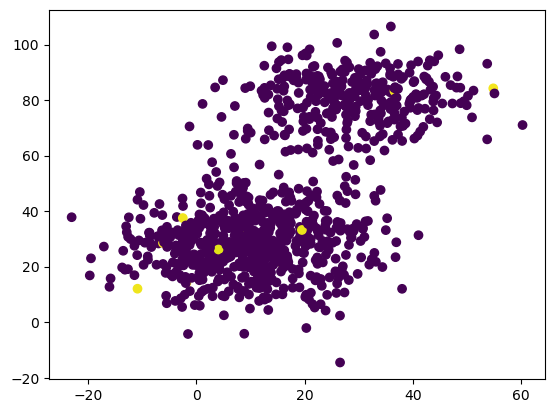

In [37]:
plot_vl(G)

In [38]:
print_infected(G)

32: 49.750409327364714
59: 51.5511388955525
239: 51.16619304210931
420: 50.48899524376734
491: 49.348940672191574
520: 50.693628190796005
587: 50.301340372994225
647: 50.683956926231744
752: 49.15342319527998
851: 49.896603024513986


In [39]:
# higher k means the infection chance is more like a threshold and less gradual
# x0 represents the viral load at which someone is 50% likely to infect someone
infect_k = 0.1
infect_x0 = 250

def infection_chance(node, graph, k = infect_k, x0 = infect_x0):
    vl = get_vl(node, graph)
    return 1 / (1 + np.exp(-k * (vl - x0)))

In [40]:
vlchange_L = 1000000
vlchange_k = 3
vlchange_x0 = 3

def unsuppressed_derivative_function(viral_load, L = vlchange_L, k = vlchange_k, x0 = vlchange_x0):
    week = x0 - np.log((L - viral_load) / viral_load) / k
    return L / (1 + np.exp(-k * (week + 1 - x0)))

def unsuppressed_vl_change(node, graph):
    vl = get_vl(node, graph)
    set_vl(node, unsuppressed_derivative_function(vl) - 1, graph)

In [41]:
def suppressed_derivative_function(viral_load):
    return -(viral_load - 45) * 0.6

def suppressed_vl_change(node, graph):
    vl = get_vl(node, graph)
    change_vl(node, suppressed_derivative_function(vl), graph)

In [42]:
death_L = 0.05
death_k = 2
death_x0 = 3.5

def death_chance(node, graph, L = death_L, k = death_k, x0 = death_x0):
    vl = get_vl(node, graph)
    return L / (1 + np.exp(-k * (np.exp(0.0002 * vl) - x0)))

In [43]:
max_antiviral_chance = 0.5
clinic_effective_radius = 1

def clinic_distance(node, graph):
    return min([node_distance(node, clinic, graph) for clinic in get_clinics(graph)])
        

def antiviral_chance(node, graph):
    effective_distance = clinic_distance(node, graph) / clinic_effective_radius
    return np.exp(1 / (effective_distance ** 2 - 1)) if effective_distance < 1 else 0

In [44]:
def mean_clinic_distance(graph = G):
    return np.mean([clinic_distance(node, graph) for node in get_people(graph)])

In [45]:
def tick_graph(graph):
    # determine deaths from unsuppressed viral load
    killed = []
    for node in get_people(graph):
        if is_infected(node, graph):
            if rand.random() < death_chance(node, graph):
                killed.append(node)
    kill_nodes(killed, graph)
    
    # determine increase/decrease in viral loads
    for node in get_people(graph):
        if is_infected(node, graph):
            if has_antiviral(node, graph):
                # antiviral suppressed progression
                suppressed_vl_change(node, graph)
            else:
                # unsuppressed progression
                unsuppressed_vl_change(node, graph)

    # determine those who will initiate antiretroviral treatment
    for node in get_people(graph):
        if is_infected(node, graph):
            if rand.random() < antiviral_chance(node, graph):
                initiate_antiviral(node, graph)
    
    # determine new infections
    newly_infected = []
    for node in get_people(graph):
        if is_infected(node, graph):
            for infectee in get_neighbors(node, graph):
                if (not is_infected(infectee, graph)) and rand.random() < infection_chance(node, graph):
                    newly_infected.append(infectee)

            for infectee in get_proximal_neighbors(node, graph):
                if (not is_infected(infectee, graph)) and rand.random() < proximal_infection_chance(node, infectee, graph):
                    newly_infected.append(infectee)
            #for infectee in get_people(graph):
            #    if (not is_infected(infectee)) and rand.random() < proximal_infection_chance(node, infectee, graph):
            #        newly_infected.append(infectee)

    # all nodes have had the chance to infect their neighbors
    # now just make them infected
    for node in newly_infected:
        infect_node(node, graph)

In [46]:
def do_ticks(n, graph):
    for i in range(0, n):
        tick_graph(graph)

In [47]:
snapshots = [0, 1, 5, 10, 50, 100, 500]

CPU times: user 2.41 s, sys: 2.07 ms, total: 2.42 s
Wall time: 2.41 s


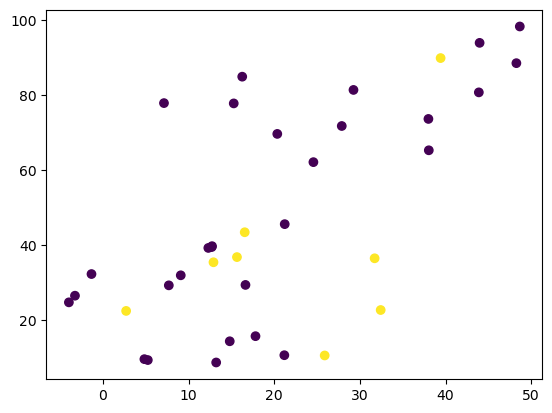

In [48]:
%%time
do_ticks(100, G)
plot_vl(G)

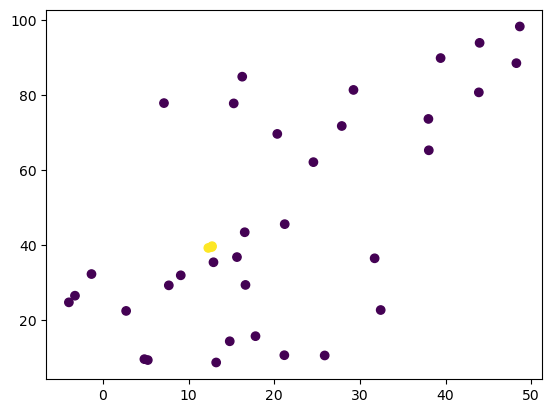

In [49]:
plot_antiviral(G)

In [50]:
# plot_antiviral(G)

In [51]:
# print_infected(G)

In [52]:
simulations_count = 50
ticks_per_simulation = 50

In [53]:
def run_simulations(population_size = population_size, 
                    edge_probability = edge_probability, 
                    num_cities = num_cities, 
                    initial_infection_probability = initial_infection_probability, 
                    initial_viral_load = initial_viral_load, 
                    initial_viral_load_std = initial_viral_load_std, 
                    simulations_count = simulations_count, 
                    ticks_per_simulation = ticks_per_simulation):
    plot_points = []
    
    for i in range(0, simulations_count):
        graph = setup_simulation()

        clinic_distance = mean_clinic_distance(graph)
        
        do_ticks(
            ticks_per_simulation, 
            graph)

        plot_points.append((clinic_distance, 100 * (1 - (graph.number_of_nodes() / population_size))))
        # get stats about the graph
        print(f'Simulation {i}:\n{100 * (1 - (graph.number_of_nodes() / population_size))}% casualty rate\n{clinic_distance} mean clinic distance')

    return plot_points

In [54]:
%%time
points = run_simulations()

Simulation 0:
83.5% casualty rate
40.83533743930969 mean hospital distance
Simulation 1:
87.3% casualty rate
24.005712874519368 mean hospital distance
Simulation 2:
87.5% casualty rate
15.262467216110531 mean hospital distance
Simulation 3:
90.0% casualty rate
17.31589117178513 mean hospital distance
Simulation 4:
86.9% casualty rate
16.11517940744953 mean hospital distance
Simulation 5:
86.1% casualty rate
14.050259785682536 mean hospital distance
Simulation 6:
85.6% casualty rate
15.750980372236192 mean hospital distance
Simulation 7:
85.8% casualty rate
15.771330316554778 mean hospital distance
Simulation 8:
87.0% casualty rate
16.817270441016053 mean hospital distance
Simulation 9:
88.1% casualty rate
26.521401257216155 mean hospital distance
Simulation 10:
87.3% casualty rate
24.972403434993403 mean hospital distance
Simulation 11:
89.2% casualty rate
26.504159983688652 mean hospital distance
Simulation 12:
86.1% casualty rate
34.62759197585413 mean hospital distance
Simulation 13

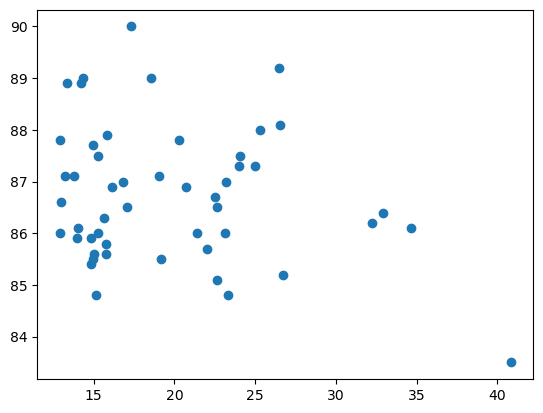

In [55]:
x, y = zip(*points)
plt.scatter(x, y)
plt.show()